# 🍷 Normalization — Wine Dataset

**Dataset:** Wine dataset(`wine_data.csv`)  
**Goal:** Scale features to a 0-1 range using Min-Max Normalization

### What this notebook covers:
- Loading and inspecting Wine dataset
- Understanding why normalization is needed
- Applying MinMaxScaler from Scikit-learn
- Comparing original vs normalized distributions

## 📦 Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Loading Dataset
Loading only 3 columns: class label, alcohol and malic acid for simplicity.

df=pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])

## ✏️ Renaming Columns
Giving meaningful names to the columns for better readability.

In [28]:
df.columns=['class Label','Alcohal','Malic acid']

In [29]:
df.sample(5)

,class Label,Alcohal,Malic acid
93,2,12.29,2.83
116,2,11.82,1.47
115,2,11.03,1.51
132,3,12.81,2.31
175,3,13.27,4.28


In [6]:
df.shape

(178, 3)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class Label  178 non-null    int64  
 1   Alcohal      178 non-null    float64
 2   Malic acid   178 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.3 KB


In [8]:
df.describe()

,class Label,Alcohal,Malic acid
count,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348
std,0.775035,0.811827,1.117146
min,1.000000,11.030000,0.740000
25%,1.000000,12.362500,1.602500
50%,2.000000,13.050000,1.865000
75%,3.000000,13.677500,3.082500
max,3.000000,14.830000,5.800000


In [9]:
df.corr()

,class Label,Alcohal,Malic acid
class Label,1.000000,-0.328222,0.437776
Alcohal,-0.328222,1.000000,0.094397
Malic acid,0.437776,0.094397,1.000000


<Axes: xlabel='Alcohal', ylabel='Density'>

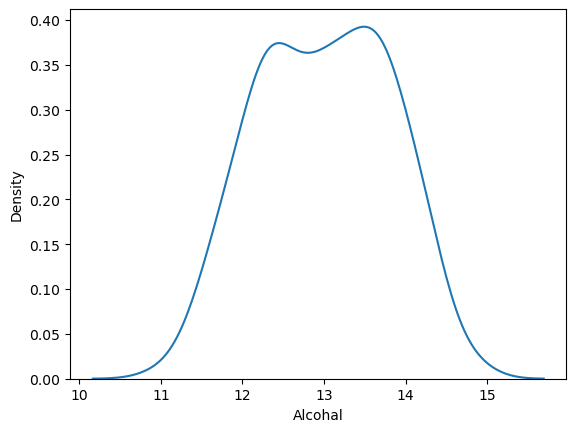

In [10]:
sns.kdeplot(df['Alcohal'])

<Axes: xlabel='Malic acid', ylabel='Density'>

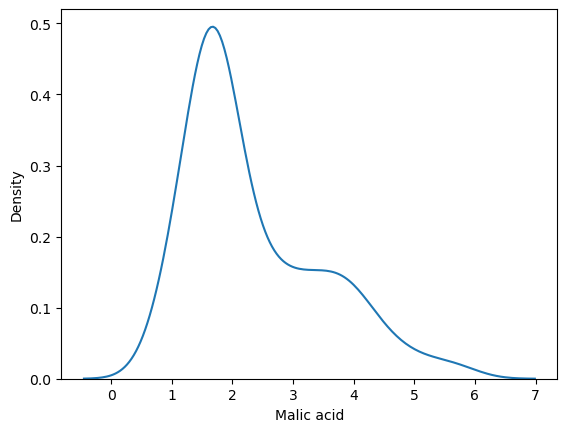

In [11]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohal', ylabel='Malic acid'>

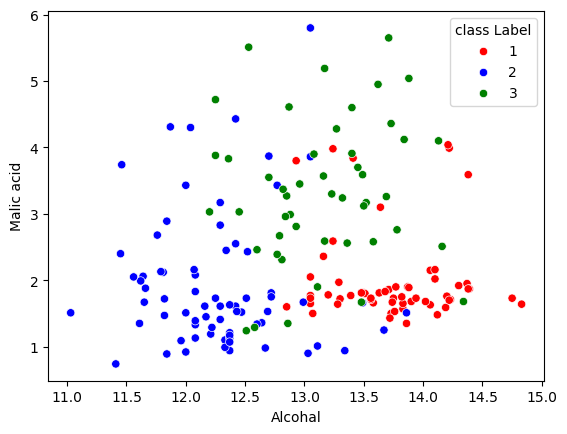

In [12]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(x=df['Alcohal'],y=df['Malic acid'],hue=df['class Label'],palette=color_dict)

## ⚙️ Applying Min-Max Normalization
Scaling all values to range [0, 1] so no feature dominates due to magnitude.

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test =train_test_split(df.drop('class Label',axis=1),
                                              df['class Label'],
                                              test_size=0.3,
                                               random_state=0
                                            )
X_train.shape,X_test.shape

((124, 2), (54, 2))

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [15]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [16]:
np.round(X_train.describe(),1)

,Alcohal,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [17]:
np.round(X_train_scaled.describe(),1)

,Alcohal,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


## 📊 Visualizing Before vs After Normalization
Comparing original and normalized distributions side by side.

Text(0.5, 1.0, 'After_scaling')

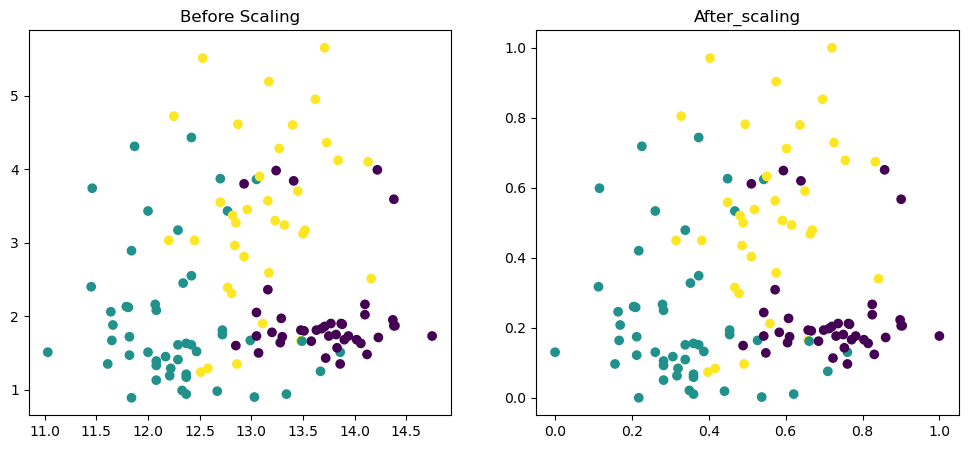

In [18]:
fig, (ax1,ax2) =plt.subplots(ncols=2, figsize =(12,5))
ax1.scatter(X_train['Alcohal'],X_train['Malic acid'],c=Y_train)
ax1.set_title('Before Scaling')

ax2.scatter(X_train_scaled['Alcohal'],X_train_scaled['Malic acid'],c=Y_train)
ax2.set_title('After_scaling')

Text(0.5, 1.0, 'Ater Scaling')

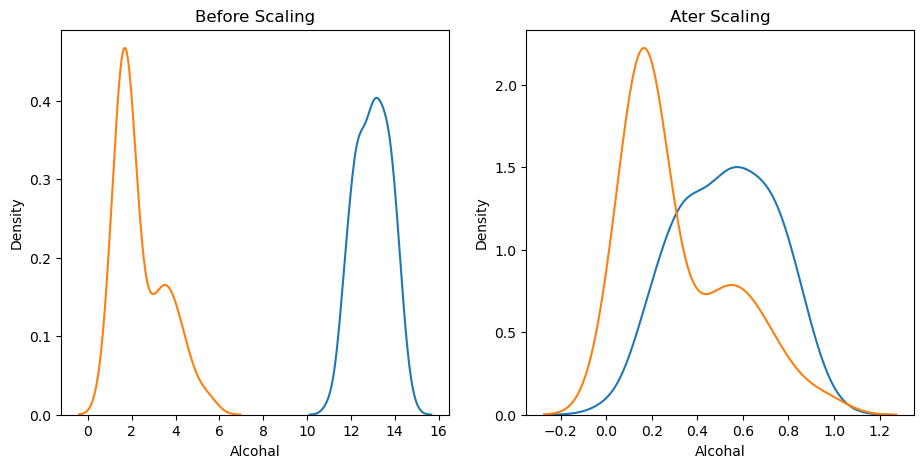

In [19]:
fig,(ax1,ax2) = plt.subplots(ncols=2, figsize =(11,5))
sns.kdeplot(X_train['Alcohal'],ax=ax1)
sns.kdeplot(X_train['Malic acid'],ax=ax1)
ax1.set_title('Before Scaling')

sns.kdeplot(X_train_scaled['Alcohal'],ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'],ax=ax2)
ax2.set_title('Ater Scaling')

Text(0.5, 1.0, 'After Scaling')

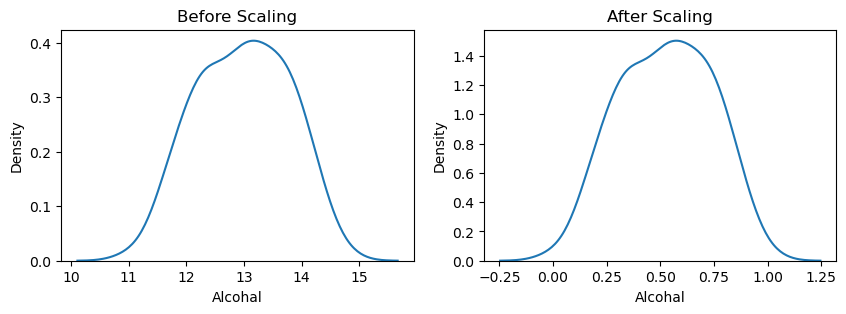

In [20]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(10,3))
sns.kdeplot(X_train['Alcohal'],ax=ax1)
ax1.set_title('Before Scaling')
sns.kdeplot(X_train_scaled['Alcohal'],ax=ax2)
ax2.set_title('After Scaling')

Text(0.5, 1.0, 'After scaling')

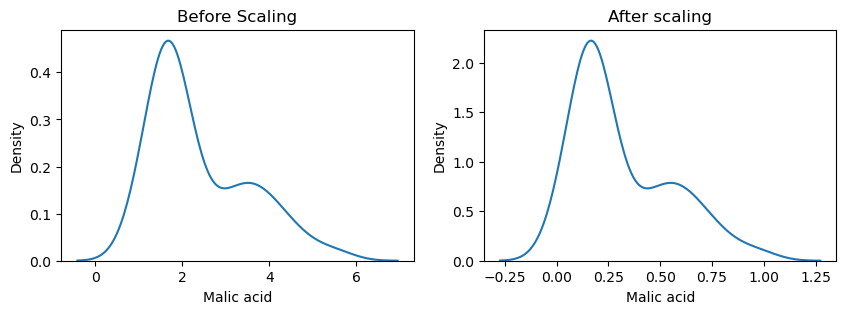

In [21]:

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(10,3))
sns.kdeplot(X_train['Malic acid'],ax=ax1)
ax1.set_title('Before Scaling')
sns.kdeplot(X_train_scaled['Malic acid'],ax=ax2)
ax2.set_title('After scaling')